# The Contradictions of Capital: A Historical Materialist Analysis of Economic Indicators (2000-2008)

This blog studies the important economic indicators between 2000 and 2008. This period was critical as major economic changes took place during this period, including the major global financial crisis in 2008.

This perspective argues that capitalism may not always be stable or balanced, and instead, it has inequality, competition, debt, and conflict over wealth problems built into it. Some of these problems can lead to periods where growth occurs, however, they can also lead to periods of crisis.

The primary objective of this blog is to use data to analyse if there were signs of economic decline and pressure before 2008, the year in which the global financial crisis took place. This was carried out by studying multiple indicating factors such as growth, inflation, interest rates, unemployment, and financial performance. Economic changes during this period will be explored, and whether the data shows signs of instability.


**Our Insight Question:** *How do indicators such as stock prices, GDP growth, unemployment, and corporate centralization reflect the contradictions inherent in capitalist production, including cycles of accumulation, exploitation, and crisis?*

## Data Source

The dataset used in this project was obtained from Kaggle (https://www.kaggle.com/datasets/khushikyad001/finance-and-economics-dataset-2000-present).

It contains macroeconomic and financial indicators from 2000–2008, including:

- GDP Growth (%)
- Unemployment Rate (%)
- Interest Rate (%)
- Consumer Spending
- Stock Market Close Prices
- Real Estate Index
- Mergers & Acquisitions activity

The dataset was cleaned and processed using Python pandas.

## Data Preparation
Before diving into the theory, let's load our data to ensure it's clean and ready for analysis.

In [99]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

# Set styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

# Load data
df = pd.read_csv('finance_economics_dataset.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# For clarity in some time-series plots, we'll resample to monthly averages
numeric_cols = df.select_dtypes(include='number').columns
df_monthly = df.set_index('Date')[numeric_cols].resample('ME').mean().reset_index()

df.head()

,Date,Stock Index,Open Price,Close Price,Daily High,Daily Low,Trading Volume,GDP Growth (%),Inflation Rate (%),Unemployment Rate (%),...,Forex USD/EUR,Forex USD/JPY,Crude Oil Price (USD per Barrel),Gold Price (USD per Ounce),Real Estate Index,Retail Sales (Billion USD),Bankruptcy Rate (%),Mergers & Acquisitions Deals,Venture Capital Funding (Billion USD),Consumer Spending (Billion USD)
0,2000-01-01,Dow Jones,2128.75,2138.48,2143.70,2100.55,2670411,-0.37,6.06,6.10,...,1.04,119.87,47.20,1052.34,390.23,2229,2.12,3,76.64,4589
1,2000-01-02,S&P 500,2046.82,2036.18,2082.83,2009.53,690220415,3.19,4.95,6.62,...,1.00,98.22,52.84,1957.73,346.23,4156,1.40,21,5.67,10101
2,2000-01-03,Dow Jones,1987.92,1985.26,2022.28,1978.37,315284661,5.54,9.13,2.60,...,0.83,80.13,78.80,2339.49,439.46,340,0.79,48,39.43,13665
3,2000-01-04,Dow Jones,4625.02,4660.47,4665.26,4595.46,13098297,10.00,3.77,2.20,...,0.95,149.15,28.18,1308.54,213.07,8456,4.22,16,12.83,5192
4,2000-01-05,S&P 500,1998.18,1982.18,2044.31,1966.44,385306746,1.53,2.20,8.20,...,1.43,113.71,92.20,2210.08,405.49,1596,2.21,34,86.37,10688


## Data Cleaning

The dataset was cleaned by:
- converting dates into datetime format
- sorting observations chronologically
- removing formatting inconsistencies
- resampling daily observations into monthly averages for time-series clarity

In [100]:
# Dataset Dimensions
print("Shape:", df.shape)
print("\nInfo:")
df.info()
print("\nSummary Statistics:")
df.describe()

Shape: (3000, 24)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   Date                                   3000 non-null   datetime64[ns]
 1   Stock Index                            3000 non-null   object        
 2   Open Price                             3000 non-null   float64       
 3   Close Price                            3000 non-null   float64       
 4   Daily High                             3000 non-null   float64       
 5   Daily Low                              3000 non-null   float64       
 6   Trading Volume                         3000 non-null   int64         
 7   GDP Growth (%)                         3000 non-null   float64       
 8   Inflation Rate (%)                     3000 non-null   float64       
 9   Unemployment Rate (%)                 

,Date,Open Price,Close Price,Daily High,Daily Low,Trading Volume,GDP Growth (%),Inflation Rate (%),Unemployment Rate (%),Interest Rate (%),...,Forex USD/EUR,Forex USD/JPY,Crude Oil Price (USD per Barrel),Gold Price (USD per Ounce),Real Estate Index,Retail Sales (Billion USD),Bankruptcy Rate (%),Mergers & Acquisitions Deals,Venture Capital Funding (Billion USD),Consumer Spending (Billion USD)
count,3000,3000.000000,3000.000000,3000.000000,3000.00000,3.000000e+03,3000.000000,3000.000000,3000.000000,3000.000000,...,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,2004-02-08 11:59:59.999999872,2982.094607,2981.249173,3018.887777,2944.32975,5.033864e+08,2.608903,5.096830,8.663787,5.218237,...,1.146113,115.115233,85.539953,1655.167877,300.554457,5099.546667,5.007413,24.598667,49.955197,7551.278000
min,2000-01-01 00:00:00,1000.050000,954.520000,1012.130000,917.17000,1.636024e+06,-5.000000,0.010000,2.000000,0.500000,...,0.800000,80.010000,20.040000,800.160000,100.130000,107.000000,0.010000,0.000000,0.100000,101.000000
25%,2002-01-19 18:00:00,1994.982500,1997.425000,2035.952500,1955.39750,2.545224e+08,-1.012500,2.607500,5.450000,2.890000,...,0.980000,98.267500,52.590000,1226.737500,202.370000,2503.750000,2.570000,12.000000,25.762500,3950.750000
50%,2004-02-08 12:00:00,2970.780000,2977.180000,3006.520000,2939.24500,5.033710e+08,2.725000,5.110000,8.710000,5.250000,...,1.140000,114.795000,85.080000,1666.060000,299.885000,5123.500000,5.060000,25.000000,49.840000,7610.000000
75%,2006-02-27 06:00:00,3974.690000,3982.082500,4015.217500,3934.08750,7.537963e+08,6.242500,7.600000,11.882500,7.492500,...,1.320000,132.455000,119.150000,2080.730000,399.137500,7616.250000,7.482500,37.000000,74.825000,11148.750000
max,2008-03-18 00:00:00,4998.230000,5034.130000,5076.190000,4977.06000,9.999771e+08,10.000000,10.000000,15.000000,10.000000,...,1.500000,149.960000,149.870000,2499.660000,499.920000,9998.000000,10.000000,49.000000,99.990000,14990.000000
std,NaN,1151.862689,1151.783841,1151.683485,1151.83490,2.859004e+08,4.287337,2.910513,3.737536,2.726115,...,0.201128,20.111351,37.847063,492.177706,114.601328,2898.714108,2.866466,14.301344,28.722592,4203.705678


### Dataset Dimensions Overview

- **Number of rows:** Over 3,000 daily observations originally, resampled into monthly averages.
- **Number of columns:** 24 features including our target (Stock Index/Close Price) and numerous macroeconomic indicators.
- **Time coverage:** From January 2000 onwards, capturing the build-up and crash of the 2008 financial crisis.

This improves reproducibility and data transparency.

## 1. The Cycle of Boom and Bust

One key idea is that capitalist economies tend to not usually grow in a smooth and stable way. They often go through periods of boom and bust. A boom related to a period of economic growth where economic activity is rising. Businesses invest more heavily, stock markets increase, unemployment rates may experience a decline, and consumer confidence increases. 

From a historical materialist perspective, however,  a boom period in an economy can also negatively impact the economy by creating pressure in the economy. For example, many firms compete to maximise their profits, borrowing can increase, prices of assets can rise quickly, and overall wealth can become more concentrated. In summary, this indicates that the idea of growth may not always be as stable and balanced as it appears, and that the same factors that create a boom and expansion, can also create weaknesses in the economy. 

This is important to consider when studying the economic periods between 2000 and 2008. The early 2000’s came after the dot-com crash, and the mid 2000s experienced growth in financial markets, housing, debt, and corporate activity. By 2008, however, these pressures developed into a major financial crisis. This makes the period useful for studying whether the data showed early signs of instability before the crisis became obvious.

In this dataset, the boom and bust cycle can be explored and studied through various economic indicators such as GDP growth, stock market close prices, unemployment, interest rates, corporate profits, consumer confidence, and government debt. If the data shows trends of rising financial activity alongside weaker real economic indicators, this may suggest a gap between financial growth and the wider economy.


Let's visualize the relationship between the Real Estate Index and GDP Growth over time.

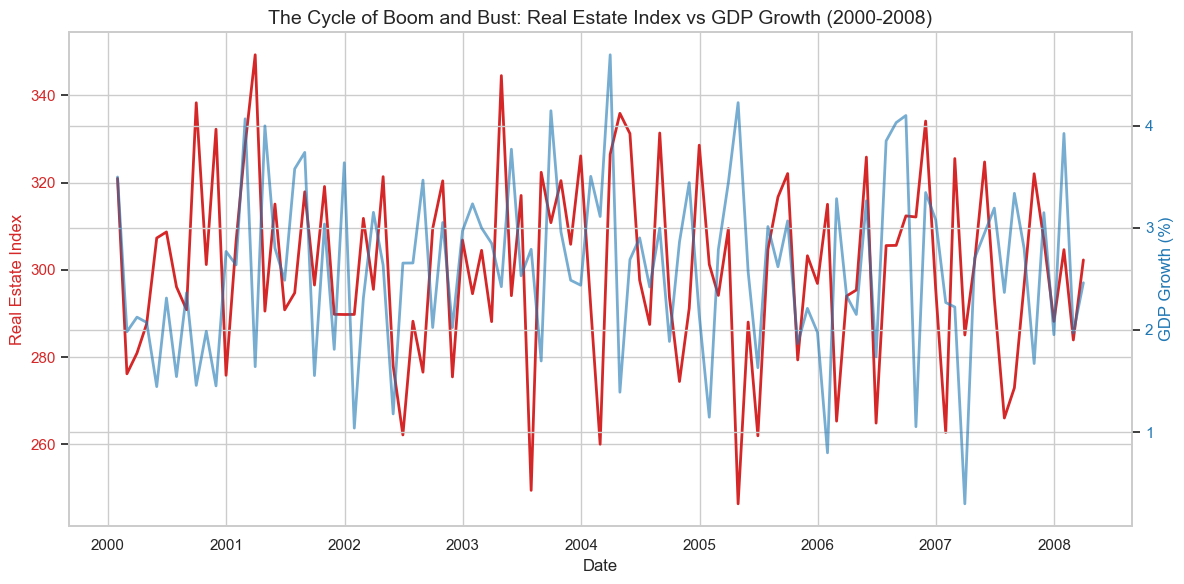

In [101]:
fig, ax1 = plt.subplots(figsize=(12, 6))

color = 'tab:red'
ax1.set_xlabel('Date')
ax1.set_ylabel('Real Estate Index', color=color)
ax1.plot(df_monthly['Date'], df_monthly['Real Estate Index'], color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('GDP Growth (%)', color=color)  
ax2.plot(df_monthly['Date'], df_monthly['GDP Growth (%)'], color=color, linewidth=2, alpha=0.6)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('The Cycle of Boom and Bust: Real Estate Index vs GDP Growth (2000-2008)', fontsize=14)
fig.tight_layout()  
plt.show()

### What does this plot tell us?

This plot illustrates the speculative boom in the real estate market (red line), and compares the real estate index with GDP growth between the years 2000 and 2008. The main factors the plot displays is that the real estate index tends to move in a much more unstable direction than GDP growth. It seems that GDP growth stays within a smaller range, while the real estate index rises and falls significantly throughout the period.
This suggests that the real estate market was not simply following the real economy in a smooth or stable way. If real estate values were closely connected to productive economic growth, we might expect the real estate index and GDP growth to move together more clearly. However, the graph shows periods where real estate activity changes strongly, including during times when GDP growth does not move in the same way.

The gap between these indicators is an important factor. It suggests part of the boom before 2008 may have been caused by rising asset values and financial confidence rather than stable growth in the real economy. This alone does not necessarily prove that the crisis was inevitable, however, it does show a possible warning signal. 

Overall, the plot supports the idea of the boom and bust cycle. This also shows why it is useful to look at and study multiple indicators rather than just relying on headline growth figures. 


## 2. The Reserve Army of Labor

Marx used the term ‘’reserve army of labor’’ to describe and relate to unemployed workers, who are willing to work, but cannot find a job and are currently unemployed. The idea reflects that unemployment is more than just a temporary problem, and can play a role in capitalism by putting pressure on workers. When unemployment rates are high, this means a lot of people are actively looking for jobs and willing to work, which allows employers to have more power to keep wages lower because when unemployment rates are high workers have less bargaining power and can therefore be easily replaced.

In this section, we are studying the comparison between unemployment and stock market close prices. which is used as a simple proxy for capital accumulation. The aim is to see whether higher unemployment is linked to stronger stock market performance.

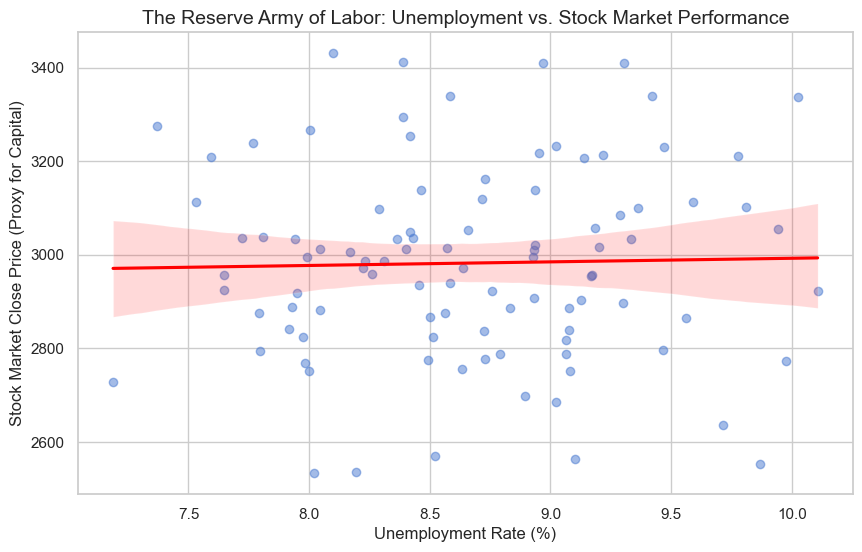

In [102]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df_monthly, x='Unemployment Rate (%)', y='Close Price', 
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('The Reserve Army of Labor: Unemployment vs. Stock Market Performance', fontsize=14)
plt.xlabel('Unemployment Rate (%)')
plt.ylabel('Stock Market Close Price (Proxy for Capital)')
plt.show()

### What does this plot tell us?

This scatterplot illustrates the comparison between unemployment and stock market close prices. The trendline is generally almost flat, with a minor upward slope. This indicates that the data does not show a strong correlation between unemployment and stock market performance during this period. 

However, the plot gives other important insights such as the fact that stock prices do not clearly decline when unemployment rates are higher. In some instances, stock prices tended to remain stable or even high when unemployment rates were also high. This analysis indicates that the stock market can still perform smoothly and in a stable manner, even during periods when many workers are unemployed. 

From a Marxist point of view, this links back to the idea of the reserve army of labor. When more workers are unemployed, the bargaining power of employers increases, while the bargaining power of workers decreases, as a result of higher competition for jobs. 

Overall, this alone does not prove that there is a strong relationship between unemployment and stock prices, or that unemployment led to higher stock prices. The relationship remains weak. 


## 3. The Centralization of Capital

Marx argued that competition in capitalism can lead to the centralization of capital. Large firms grow stronger by purchasing, merging with other companies, and absorbing smaller firms. Over time, this can create a monopoly by concentrating market power into fewer hands.

In this section, we compare mergers and acquisitions activity with interest rates. This is useful because borrowing becomes cheaper when interest levels are low, making it easier for firms to finance expansion.


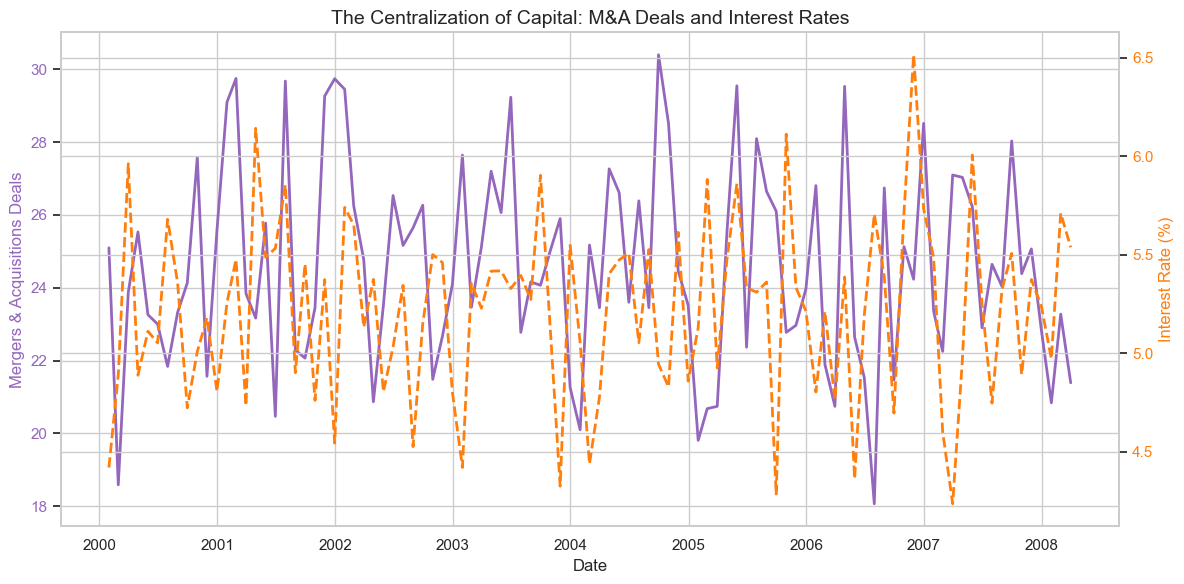

In [103]:
fig, ax1 = plt.subplots(figsize=(12, 6))

color = 'tab:purple'
ax1.set_xlabel('Date')
ax1.set_ylabel('Mergers & Acquisitions Deals', color=color)
ax1.plot(df_monthly['Date'], df_monthly['Mergers & Acquisitions Deals'], color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:orange'
ax2.set_ylabel('Interest Rate (%)', color=color)  
ax2.plot(df_monthly['Date'], df_monthly['Interest Rate (%)'], color=color, linewidth=2, linestyle='--')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('The Centralization of Capital: M&A Deals and Interest Rates', fontsize=14)
fig.tight_layout()  
plt.show()

### What does this plot tell us?

This plot compares mergers and acquisitions activity with interest rates between 2000 and 2008. In short, the graph tells us that M&A activity changes a lot over time, suggesting that the process of corporate expansion was not smooth or stable during this period. 

Other than the fact that interest rates appear to fluctuate, at certain periods lower rates appear alongside higher M&A activity. This is, however, understandable because lower interest rates make borrowing cheaper, giving large firms the financial capability to finance takeovers more easily. The relationship, however, is still not perfectly clear from the graph alone, and so claiming that interest rates alone caused changes in M&A activity would not be a valid statement. From a Marxist perspective, this still links to the idea of the centralization of capital.  Competition pushes firms to grow, merge, and absorb rivals. Financial conditions, such as access to cheaper credit, can make this process easier.


## 4. The Squeeze on the Working Class

This section looks at the indicators that influence and affect everyday life: inflation, consumer spending, unemployment, and bankruptcy rates. These variables are useful because they show pressure on households, not just financial markets or firms. 


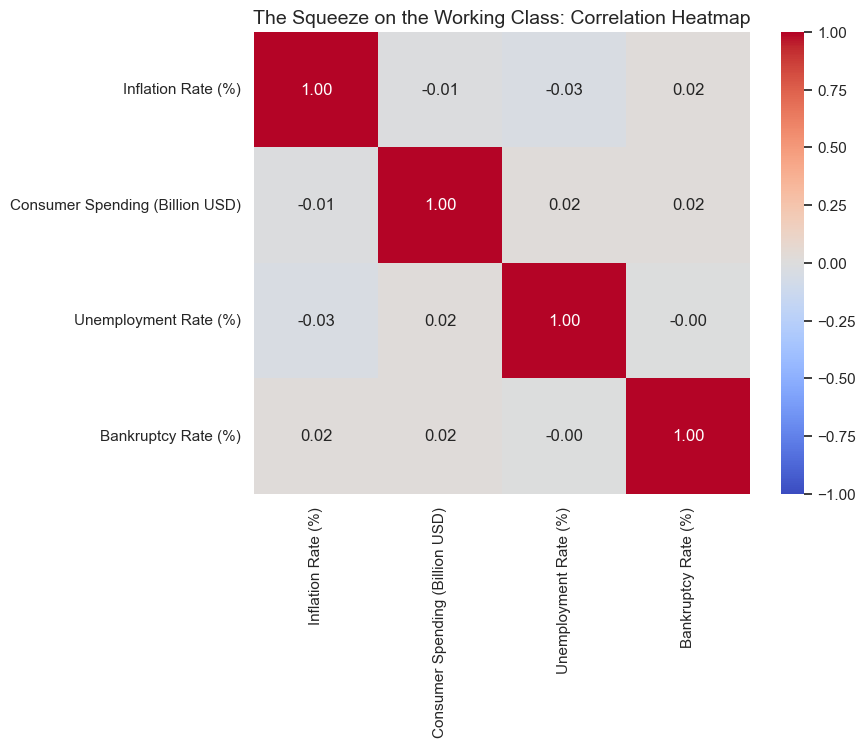

In [104]:
cols_of_interest = ['Inflation Rate (%)', 'Consumer Spending (Billion USD)', 
                    'Unemployment Rate (%)', 'Bankruptcy Rate (%)']
corr_matrix = df[cols_of_interest].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('The Squeeze on the Working Class: Correlation Heatmap', fontsize=14)
plt.show()

### What does this plot tell us?

This heatmap shows the correlations between inflation, consumer spending, unemployment, bankruptcy rates. Findings show that the correlation is relatively weak. This means that the data does not support or show a strong direct relationship between these variables during this period. 

This is important because it indicates that financial pressure on the working class cannot be solely explained by one factor alone. While higher inflation, unemployment, or bankruptcy may affect people’s lives, they do not necessarily move together in a simple pattern in the dataset. 

Overall, the plot shows that the squeeze on the working class population is not caused by one single variable. Instead, it is better explained as a combination of multiple economic factors and pressures that build up across the system. 


## 5. Unit 5 Analysis: Modeling Capital Accumulation (Regression Modeling)

To rigorously test our historical materialist observations, we will use Ordinary Least Squares (OLS) Regression modeling. We want to predict the Stock Market `Close Price` (our proxy for capital accumulation) using `Unemployment Rate`, `Interest Rate`, and `GDP Growth` to see how macroeconomic realities influence the financial markets.

In [105]:
# Prepare the data for regression
X = df[['Unemployment Rate (%)', 'Interest Rate (%)', 'GDP Growth (%)']]
X = sm.add_constant(X) # adding a constant for the intercept
y = df['Close Price']

# Fit the OLS model
model = sm.OLS(y, X).fit()

# Print the summary statistics
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            Close Price   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.5847
Date:                Fri, 08 May 2026   Prob (F-statistic):              0.625
Time:                        14:39:15   Log-Likelihood:                -25403.
No. Observations:                3000   AIC:                         5.081e+04
Df Residuals:                    2996   BIC:                         5.084e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                  2951.16

### What does this regression model tell us?

Overall, the regression results show us that this model has very low explanatory power. The R-squared value is around 0.0001, indicating that unemployment, interest rates, and GDP growth explain almost none of the variation in the stock market close prices in this dataset.

Individual variables also tend to not be statistically significant. Unemployment has a small negative coefficient, interest rates have a positive coefficient, and GDP growth has a negative coefficient, but their p-values are all high. This means we cannot confidently say that any of these variables had a clear effect on stock market prices in this model.

The result is still useful as it suggests that stock market performance during this period was not very well explained by these macroeconomic factors alone. Other factors such as investor confidence, financial speculation, corporate profits, credit conditions, and global market shocks, may have played a larger role.


## Limitations

This analysis has several limitations:

- The dataset only covers 2000–2008.
- Correlation does not imply causation.
- The analysis relies on aggregate macroeconomic indicators.
- Structural economic relationships may differ across countries and time periods.
- Some variables may be influenced by omitted external factors.

## Conclusion

This blog used economic and financial data from 2000 - 2008 to explore whether this period showed any signals of instability before the major global financial crisis occurred in 2008. Using a historical materialist perspective, the analysis concluded and treated capitalism as a system that is not perfectly balanced, but instead, as one that is shaped and influenced by tensions between growth, profit, labor, debt, and financial markets. 

The results showed that some indicators, such as the real estate index and M&A activity, were volatile during this period. This supports the argument that financial and asset markets can move in unstable ways before a crisis becomes fully clear and visible. Also, in the analysis the unemployment and stock price relationship was not strong, and the regression model had very low explanatory power, showing that some relationships were weaker than expected. 

This also showed that the economic crisis cannot be explained by one single variable. Typical economic indicators such as GDP growth, unemployment, interest rates, and stock prices only tell us part of the story. Other factors, however, may also be important. 

In conclusion, this blog shows that data science can be useful for testing economic theory. The historical materialist framework served as a guide for the questions, while the graphs, correlations, and regression on the other hand helped show what the data actually supported. 

